# Birch Reduction Code

In [1]:
import mechwolf as mw
from datetime import timedelta
import astropy.units as u

# Reagents

In [2]:
reagents = ["THF","SM"]
reagent_set = set(reagents)

print(reagents)

['THF', 'SM']


# Define Vessels

In [3]:
THF = mw.Vessel("Tetrahydrofuran", name="THF")
EDAinTHF = mw.Vessel("Tetrahydrofuran", name="EDAinTHF")
SM =mw.Vessel("Starting_material_and_tbutanol_THF", name = "SM")
EDA = mw.Vessel("Ethylene_diamine", name="EDA")
Product = mw.Vessel("Product")

In [4]:
ls /dev/serial/by-id/

usb-FTDI_FT230X_Basic_UART_DO018BBZ-if00-port0@
usb-FTDI_USB-RS422_Cable_FT1UIC5M-if00-port0@
usb-FTDI_USB-RS422_Cable_FT1WLW8P-if00-port0@


# Define Passive Components

In [5]:
def fat_tube(len):
    return mw.Tube(length=len, ID="1/16 in", OD="1/8 in", material="PFA")

def thin_tube(len):
    return mw.Tube(length=len, ID="0.030 in", OD="1/16 in", material="PFA")

def thinner_tube(len):
    return mw.Tube(length=len, ID="0.020 in", OD="1/16 in", material="PFA")


valve_tube = thinner_tube("12 cm")

column = mw.Component(name = "column")

reactor = mw.Component(name = "reactor")

T_mixer = mw.TMixer(name = "T_mixer")

In [6]:
# Define Active Components

In [7]:
# pump 1
#Get the serial port number of the pump that activates Li wire and write it here:
Li_activator_pump = mw.VarianPump(serial_port = '/dev/serial/by-id/usb-FTDI_USB-RS422_Cable_FT1UIC5M-if00-port0',
                                  max_rate='25mL/min', name="Li_activator_pump")

# pump 2
#Get the serial port number of the pump that is attached to the switching valve and write it here:
reagent_pump = mw.VarianPump(serial_port = '/dev/serial/by-id/usb-FTDI_USB-RS422_Cable_FT1WLW8P-if00-port0',
                             max_rate='5mL/min', name="reagent_pump")

# define valve
reagent_mapping = {THF: 4, SM: 5}

# amino valve
reagent_valve = mw.ViciValve(serial_port= '/dev/serial/by-id/usb-FTDI_FT230X_Basic_UART_DO018BBZ-if00-port0',
                             mapping = reagent_mapping, name="reagent_valve")


# Define Apparatus 

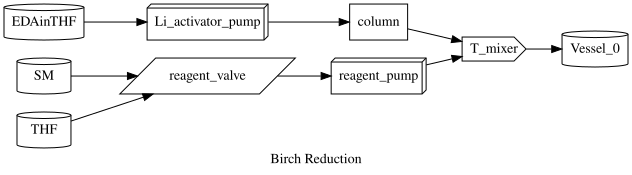

In [8]:
A = mw.Apparatus("Birch Reduction")

A.add(THF, reagent_valve, fat_tube("1 ft"))
A.add(SM, reagent_valve, fat_tube("1 ft"))
A.add(reagent_valve, reagent_pump, valve_tube)
A.add(reagent_pump, T_mixer, thinner_tube("1 ft"))

A.add(EDAinTHF, Li_activator_pump, fat_tube("1 ft"))
A.add(Li_activator_pump, column, thinner_tube("1 ft"))
A.add(column, T_mixer, thinner_tube("0.16 ft"))
A.add(T_mixer, Product, thinner_tube("15 ft"))

#A.describe()
A.visualize()
#A.summarize()

# Define Protocol 

In [9]:
P = mw.Protocol(A)
start = timedelta(seconds=0)

# how much time to leave the pumps off before and after switching the valve
switching_time = timedelta(seconds=1)

P.add(Li_activator_pump, start = start, duration = timedelta(minutes=480), rate = "0.1 mL/min")
P.add(reagent_pump, start = start, duration = timedelta(minutes=480), rate = "0.1 mL/min")
P.add(reagent_valve, start=start, duration = timedelta(minutes=480), setting="THF")

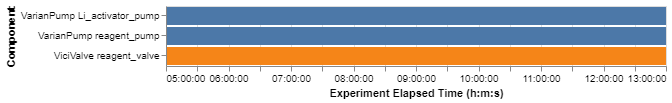

In [10]:
P.visualize()

In [11]:
exp=P.execute(dry_run=100000)

In [12]:
exp=P.execute()

Execute? [y/N]: y


In [13]:
#A.visualize(graph_attr=dict(splines="ortho", nodesep="0.75"), label_tubes=False)

P = mw.Protocol(A)
start = timedelta(seconds=0)

# how much time to leave the pumps off before and after switching the valve
switching_time = timedelta(seconds=1)

P.add(Li_activator_pump, start = start, duration = timedelta(minutes=120), rate = "0.25 mL/min")
P.add(reagent_pump, start = start, duration = timedelta(minutes=120), rate = "0.25 mL/min")
P.add(reagent_valve, start=start, duration = timedelta(minutes=120), setting="SM")

exp=P.execute()

Execute? [y/N]: y
